In [8]:

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

sns.set(style='whitegrid')

print("LIBRERIAS CARGADAS")

LIBRERIAS CARGADAS


In [9]:
Df = pd.read_csv(
    r"C:\Users\Alan\Downloads\ufc_gold_dataset_final.csv"
)

print("DATASET CARGADO")

print(Df.head())

DATASET CARGADO
                                           Fight_URL      Fighter_1  \
0  http://ufcstats.com/fight-details/4acab67848e7...   Scott Morris   
1  http://ufcstats.com/fight-details/4b9ae533ccb3...  Patrick Smith   
2  http://ufcstats.com/fight-details/00835554f95f...   Royce Gracie   
3  http://ufcstats.com/fight-details/aa161c715974...   Royce Gracie   
4  http://ufcstats.com/fight-details/8fbdde20b712...  Patrick Smith   

        Fighter_2         Winner                 Weight_Class      Method  \
0  Sean Daugherty   Scott Morris             Open Weight Bout  Submission   
1      Ray Wizard  Patrick Smith             Open Weight Bout  Submission   
2   Patrick Smith   Royce Gracie  UFC 2 Tournament Title Bout      KO/TKO   
3   Remco Pardoel   Royce Gracie             Open Weight Bout  Submission   
4   Johnny Rhodes  Patrick Smith             Open Weight Bout  Submission   

   End_Round End_Time  Total_Fight_Time_Sec    Time_Format  ...  F2_Body  \
0          1     0

In [10]:
print(Df.columns.tolist())

['Fight_URL', 'Fighter_1', 'Fighter_2', 'Winner', 'Weight_Class', 'Method', 'End_Round', 'End_Time', 'Total_Fight_Time_Sec', 'Time_Format', 'F1_KD', 'F2_KD', 'F1_Sig_Landed', 'F1_Sig_Att', 'F2_Sig_Landed', 'F2_Sig_Att', 'F1_TD_Landed', 'F2_TD_Landed', 'F1_TD_Att', 'F2_TD_Att', 'F1_Sub_Att', 'F2_Sub_Att', 'F1_Ctrl_Sec', 'F2_Ctrl_Sec', 'F1_Head', 'F2_Head', 'F1_Body', 'F2_Body', 'F1_Leg', 'F2_Leg', 'F1_Distance', 'F2_Distance', 'F1_Clinch', 'F2_Clinch', 'F1_Ground', 'F2_Ground', 'Event_Date']


In [11]:
def CategorizarFinalizacion(X):

    X = str(X).upper()

    if 'KO' in X or 'TKO' in X:
        return 'KO/TKO'

    elif 'SUB' in X:
        return 'Submission'

    else:
        return 'Decision'


Df['finish_method'] = Df['Method'].apply(
    CategorizarFinalizacion
)

print(
    Df['finish_method'].value_counts()
)

finish_method
Decision      4111
KO/TKO        2785
Submission    1655
Name: count, dtype: int64


In [12]:
# PRECISION DE GOLPEO

Df['F1_SIG_STR_pct'] = (
    Df['F1_Sig_Landed'] /
    Df['F1_Sig_Att']
)

# DEFENSA DE DERRIBOS

Df['F1_TD_Defense'] = 1 - (
    Df['F2_TD_Landed'] /
    (Df['F2_TD_Att'] + 1)
)

print(Df.head())

                                           Fight_URL      Fighter_1  \
0  http://ufcstats.com/fight-details/4acab67848e7...   Scott Morris   
1  http://ufcstats.com/fight-details/4b9ae533ccb3...  Patrick Smith   
2  http://ufcstats.com/fight-details/00835554f95f...   Royce Gracie   
3  http://ufcstats.com/fight-details/aa161c715974...   Royce Gracie   
4  http://ufcstats.com/fight-details/8fbdde20b712...  Patrick Smith   

        Fighter_2         Winner                 Weight_Class      Method  \
0  Sean Daugherty   Scott Morris             Open Weight Bout  Submission   
1      Ray Wizard  Patrick Smith             Open Weight Bout  Submission   
2   Patrick Smith   Royce Gracie  UFC 2 Tournament Title Bout      KO/TKO   
3   Remco Pardoel   Royce Gracie             Open Weight Bout  Submission   
4   Johnny Rhodes  Patrick Smith             Open Weight Bout  Submission   

   End_Round End_Time  Total_Fight_Time_Sec    Time_Format  ...  F1_Distance  \
0          1     0:20         

In [13]:
Columnas = [

    'F1_Distance',
    'F1_SIG_STR_pct',
    'F1_TD_Defense',
    'Weight_Class',
    'finish_method'
]

Df_Modelo = Df[Columnas].copy()

print(Df_Modelo.head())

   F1_Distance  F1_SIG_STR_pct  F1_TD_Defense                 Weight_Class  \
0            0        1.000000            1.0             Open Weight Bout   
1            0        1.000000            1.0             Open Weight Bout   
2            0        1.000000            1.0  UFC 2 Tournament Title Bout   
3            0             NaN            1.0             Open Weight Bout   
4            3        0.416667            1.0             Open Weight Bout   

  finish_method  
0    Submission  
1    Submission  
2        KO/TKO  
3    Submission  
4    Submission  


In [14]:
Df_Modelo = Df_Modelo.replace(
    [np.inf, -np.inf],
    np.nan
)

Df_Modelo = Df_Modelo.dropna()

print(Df_Modelo.shape)

(8512, 5)


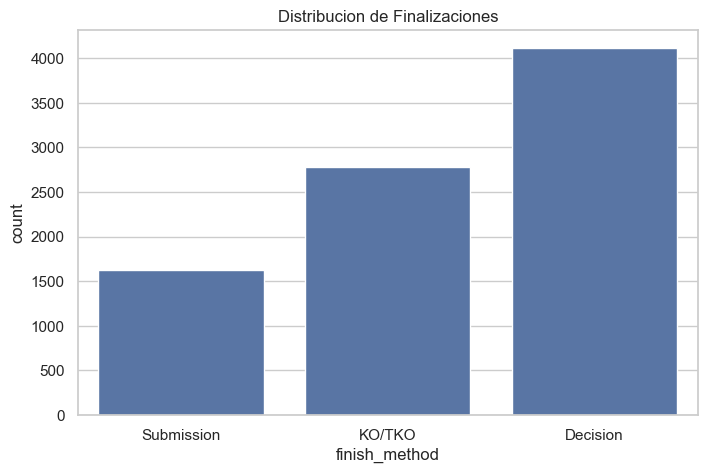

In [15]:
plt.figure(figsize=(8,5))

sns.countplot(

    data=Df_Modelo,

    x='finish_method'
)

plt.title('Distribucion de Finalizaciones')

plt.show()

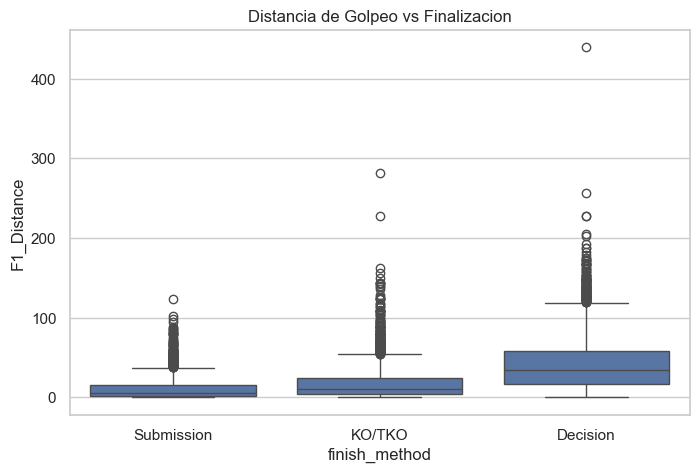

In [16]:
plt.figure(figsize=(8,5))

sns.boxplot(

    data=Df_Modelo,

    x='finish_method',

    y='F1_Distance'
)

plt.title('Distancia de Golpeo vs Finalizacion')

plt.show()

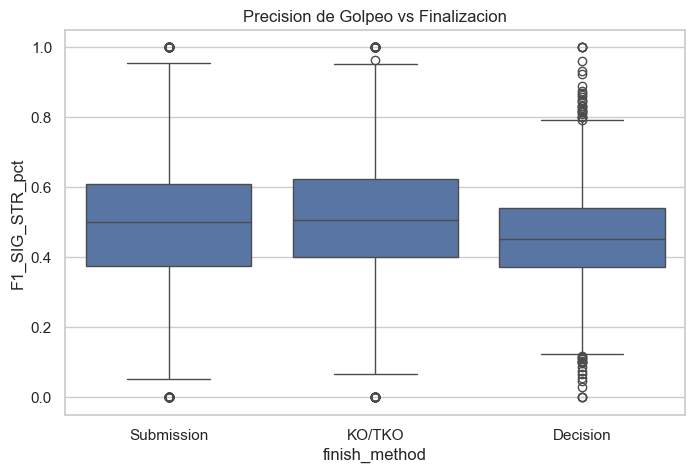

In [17]:
plt.figure(figsize=(8,5))

sns.boxplot(

    data=Df_Modelo,

    x='finish_method',

    y='F1_SIG_STR_pct'
)

plt.title('Precision de Golpeo vs Finalizacion')

plt.show()

In [18]:
Le_Weight = LabelEncoder()

Le_Target = LabelEncoder()

Df_Modelo['Weight_Class'] = (

    Le_Weight.fit_transform(
        Df_Modelo['Weight_Class']
    )
)

Df_Modelo['finish_method'] = (

    Le_Target.fit_transform(
        Df_Modelo['finish_method']
    )
)

print(Df_Modelo.head())

   F1_Distance  F1_SIG_STR_pct  F1_TD_Defense  Weight_Class  finish_method
0            0        1.000000            1.0             8              2
1            0        1.000000            1.0             8              2
2            0        1.000000            1.0            29              1
4            3        0.416667            1.0             8              2
6            0        1.000000            1.0             8              1


In [19]:
X = Df_Modelo.drop(
    'finish_method',
    axis=1
)

y = Df_Modelo['finish_method']

print(X.head())

   F1_Distance  F1_SIG_STR_pct  F1_TD_Defense  Weight_Class
0            0        1.000000            1.0             8
1            0        1.000000            1.0             8
2            0        1.000000            1.0            29
4            3        0.416667            1.0             8
6            0        1.000000            1.0             8


In [20]:
X_Train, X_Test, y_Train, y_Test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42
)

print("DATOS DIVIDIDOS")

DATOS DIVIDIDOS


In [21]:
Modelo = DecisionTreeClassifier(

    criterion='gini',

    max_depth=5,

    random_state=42
)

Modelo.fit(
    X_Train,
    y_Train
)

print("MODELO ENTRENADO")

MODELO ENTRENADO


In [22]:
y_Pred = Modelo.predict(X_Test)

print(y_Pred[:10])

[0 1 0 1 0 0 0 0 0 1]


In [23]:
Accuracy = accuracy_score(
    y_Test,
    y_Pred
)

print("ACCURACY")
print(Accuracy)

ACCURACY
0.623018203170875


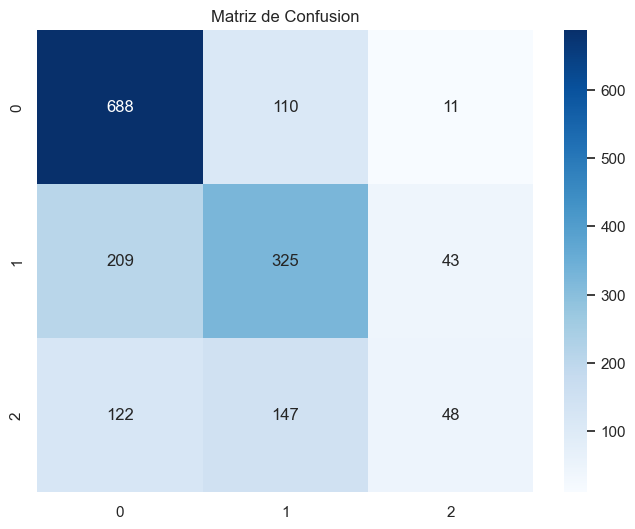

In [24]:
plt.figure(figsize=(8,6))

sns.heatmap(

    confusion_matrix(
        y_Test,
        y_Pred
    ),

    annot=True,

    fmt='d',

    cmap='Blues'
)

plt.title('Matriz de Confusion')

plt.show()

In [29]:
Importancias = pd.DataFrame({

    'Variable': X.columns,

    'Importancia': Modelo.feature_importances_
})

Importancias = Importancias.sort_values(

    by='Importancia',

    ascending=False
)

print(Importancias)

         Variable  Importancia
0     F1_Distance     0.746133
2   F1_TD_Defense     0.167799
1  F1_SIG_STR_pct     0.070053
3    Weight_Class     0.016015


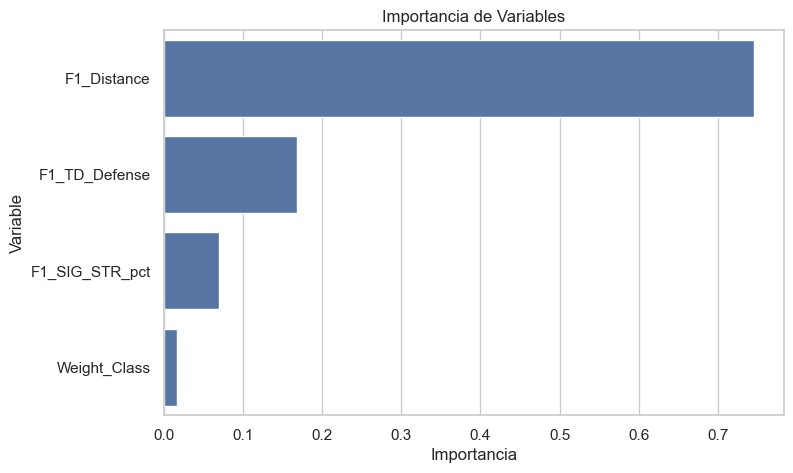

In [30]:
plt.figure(figsize=(8,5))

sns.barplot(

    data=Importancias,

    x='Importancia',

    y='Variable'
)

plt.title('Importancia de Variables')

plt.show()

In [31]:
print("INTERPRETACION DEL MODELO")
print()

for Variable, Importancia in zip(

    Importancias['Variable'],
    Importancias['Importancia']
):

    print(
        f"{Variable}: {round(Importancia,4)}"
    )

INTERPRETACION DEL MODELO

F1_Distance: 0.7461
F1_TD_Defense: 0.1678
F1_SIG_STR_pct: 0.0701
Weight_Class: 0.016
